# 📊 Notebook 03 — Model Evaluation
**FracAtlas YOLOv12m Fracture Detection Pipeline**

Evaluates the trained model on the held-out test set and generates all required
visualisations for scientific publication.


## 0. Imports

In [13]:
# Enable inline plotting for Jupyter notebooks
%matplotlib inline

import os, json, yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from ultralytics import YOLO
from sklearn.metrics import (precision_recall_curve, average_precision_score,
                             confusion_matrix, ConfusionMatrixDisplay, f1_score)
from tqdm import tqdm

# Configure matplotlib to display figures inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.bbox'] = 'tight'

SAVE_DPI = 150
OUTPUT_FIGS = Path(".")  # Save evaluation figures to project root
print("✅ Libraries loaded")
print("📊 Figures will be displayed inline and saved to:", OUTPUT_FIGS.absolute())


✅ Libraries loaded
📊 Figures will be displayed inline and saved to: d:\Project Medical Object Detection\FracAtlas\notebooks


## 1. Paths & Model

In [14]:
from pathlib import Path

# Set path absolut ke folder utama proyek
BASE_DIR   = Path(r"D:\Project Medical Object Detection\FracAtlas")
RUNS_DIR   = BASE_DIR / "runs-old-v8m-adamw" / "detect"
RUN_NAME   = "fracatlas_yolov8m_adamw"
YAML_PATH  = BASE_DIR / "fracatlas_hand_oversampled.yaml"
BEST_MODEL = RUNS_DIR / RUN_NAME / "weights" / "best.pt"


assert BEST_MODEL.exists(), f"❌ best.pt not found: {BEST_MODEL}\nRun Notebook 02 first."

model = YOLO(str(BEST_MODEL))
print(f"✅ Loaded model: {BEST_MODEL}")

with open(YAML_PATH) as f:
    data_cfg = yaml.safe_load(f)

dataset_path = Path(data_cfg["path"])
test_img_dir = dataset_path / "test" / "images"
test_lbl_dir = dataset_path / "test" / "labels"
print(f"Test images: {len(list(test_img_dir.iterdir()))}")


✅ Loaded model: D:\Project Medical Object Detection\FracAtlas\runs-old-v8m-adamw\detect\fracatlas_yolov8m_adamw\weights\best.pt
Test images: 362


## 2. Run Ultralytics Built-in Validation (mAP, P, R, F1)

In [15]:
# Official YOLO validation on the test split
val_results = model.val(
    data      = str(YAML_PATH),
    split     = "test",
    imgsz     = 640,
    conf      = 0.001,      # Default detection threshold
    iou       = 0.5,
    plots     = True,
    save_json = False,
    project   = str(RUNS_DIR),
    name      = RUN_NAME + "_eval",
    exist_ok  = True,
)

# Extract metrics
mp      = float(val_results.results_dict.get("metrics/precision(B)", 0))
mr      = float(val_results.results_dict.get("metrics/recall(B)", 0))
map50   = float(val_results.results_dict.get("metrics/mAP50(B)", 0))
map5095 = float(val_results.results_dict.get("metrics/mAP50-95(B)", 0))
f1_val  = 2 * mp * mr / (mp + mr) if (mp + mr) > 0 else 0

print("\n" + "="*50)
print("  TEST SET PERFORMANCE METRICS")
print("="*50)
print(f"  Precision  : {mp:.4f}")
print(f"  Recall     : {mr:.4f}")
print(f"  F1-Score   : {f1_val:.4f}")
print(f"  mAP@50     : {map50:.4f}")
print(f"  mAP@50-95  : {map5095:.4f}")
print("="*50)


Ultralytics 8.4.21  Python-3.10.19 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access  (ping: 0.50.1 ms, read: 101.6164.4 MB/s, size: 258.6 KB)
val: Scanning D:\Project Medical Object Detection\FracAtlas\yolo_dataset_hand_oversampled\test\labels.cache... 362 images, 165 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 362/362 116.3Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 2.0it/s 11.4s0.4s
                   all        362        253      0.808      0.775      0.842      0.435
Speed: 4.0ms preprocess, 21.7ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to D:\Project Medical Object Detection\FracAtlas\runs-old-v8m-adamw\detect\fracatlas_yolov8m_adamw_eval

  TEST SET PERFORMANCE METRICS
  Precision  : 0.8083
  Recall     : 0.7747
  F1-Score   : 0.7912
  mAP@50     : 0.8

## 3. Collect Raw Predictions for Custom Curves

In [16]:
# Run predictions at low confidence to collect scores for PR / F1 curves
all_scores, all_labels_gt = [], []

test_images = sorted(test_img_dir.iterdir())

for img_path in tqdm(test_images, desc="Predicting"):
    lbl_path = test_lbl_dir / (img_path.stem + ".txt")
    gt_lines = lbl_path.read_text().strip().splitlines() if lbl_path.exists() else []
    gt_boxes = len([l for l in gt_lines if l.strip()])

    preds = model.predict(str(img_path), conf=0.01, iou=0.5, verbose=False)
    boxes = preds[0].boxes if preds else None

    if boxes is not None and len(boxes) > 0:
        scores = boxes.conf.cpu().numpy()
    else:
        scores = np.array([])

    # Image-level: any GT box => positive; any pred => score
    img_gt = 1 if gt_boxes > 0 else 0
    if len(scores) > 0:
        all_scores.append(float(scores.max()))
    else:
        all_scores.append(0.0)
    all_labels_gt.append(img_gt)

all_scores   = np.array(all_scores)
all_labels_gt = np.array(all_labels_gt)
print(f"\nTotal test images : {len(all_labels_gt)}")
print(f"Positives (frac.) : {all_labels_gt.sum()}")
print(f"Negatives         : {(all_labels_gt==0).sum()}")


Predicting:   0%|          | 0/362 [00:00<?, ?it/s]

Predicting: 100%|██████████| 362/362 [00:14<00:00, 25.04it/s]


Total test images : 362
Positives (frac.) : 197
Negatives         : 165


## 4. Precision–Recall Curve

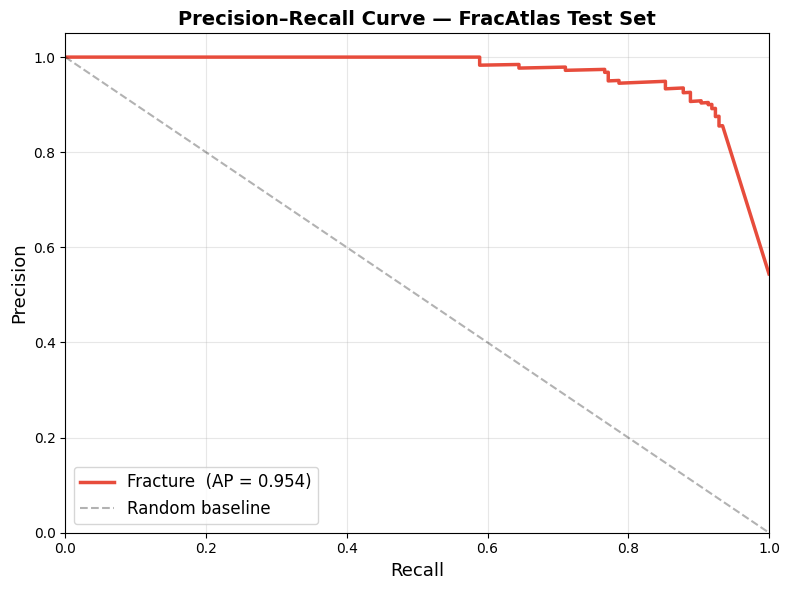

✅ Saved & displayed precision_recall_curve.png  |  AP=0.9545


In [17]:
precision_arr, recall_arr, pr_thresholds = precision_recall_curve(all_labels_gt, all_scores)
ap = average_precision_score(all_labels_gt, all_scores)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_arr, precision_arr, color="#e74c3c", linewidth=2.5,
        label=f"Fracture  (AP = {ap:.3f})")
ax.plot([0, 1], [1, 0], "k--", alpha=0.3, label="Random baseline")
ax.set_xlabel("Recall", fontsize=13)
ax.set_ylabel("Precision", fontsize=13)
ax.set_title("Precision–Recall Curve — FracAtlas Test Set", fontsize=14, fontweight="bold")
ax.legend(fontsize=12)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_FIGS / "precision_recall_curve.png", dpi=SAVE_DPI)
plt.show()  # Display the figure inline
print(f"✅ Saved & displayed precision_recall_curve.png  |  AP={ap:.4f}")


## 5. Confusion Matrix

In [ ]:
# ─── Box-Level Confusion Matrix ────────────────────────────────────────────
# Setiap predicted box dievaluasi terhadap GT box via IoU >= IOU_THRESH.
# Ini lebih tepat untuk object detection daripada image-level binary.
CONF_THRESH = 0.25   # sama seperti sebelumnya
IOU_THRESH  = 0.50

def _iou(b1, b2):
    xA, yA = max(b1[0],b2[0]), max(b1[1],b2[1])
    xB, yB = min(b1[2],b2[2]), min(b1[3],b2[3])
    inter = max(0,xB-xA)*max(0,yB-yA)
    a1 = (b1[2]-b1[0])*(b1[3]-b1[1])
    a2 = (b2[2]-b2[0])*(b2[3]-b2[1])
    u = a1+a2-inter
    return inter/u if u>0 else 0.0

tp_b = fp_b = fn_b = tn_b = 0

for img_path in tqdm(sorted(test_img_dir.iterdir()), desc="Box-level CM"):
    lbl_path = test_lbl_dir / (img_path.stem + ".txt")
    with Image.open(img_path) as _img:
        iw, ih = _img.size

    gt_boxes = []
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().splitlines():
            if not line.strip(): continue
            p = list(map(float, line.strip().split()))
            xc,yc,w,h = p[1:5]
            gt_boxes.append([(xc-w/2)*iw,(yc-h/2)*ih,(xc+w/2)*iw,(yc+h/2)*ih])

    preds = model.predict(str(img_path), conf=CONF_THRESH, iou=0.5, verbose=False)
    pred_boxes = []
    if preds and preds[0].boxes is not None and len(preds[0].boxes)>0:
        pred_boxes = [preds[0].boxes.xyxy[i].tolist() for i in range(len(preds[0].boxes))]

    if not gt_boxes and not pred_boxes:
        tn_b += 1          # background image, no false alarm
        continue
    if not gt_boxes:       # background image with false alarms
        fp_b += len(pred_boxes); continue
    if not pred_boxes:     # positive image, all GT missed
        fn_b += len(gt_boxes); continue

    matched = set()
    for pb in pred_boxes:
        best_iou, best_j = 0.0, -1
        for j, gb in enumerate(gt_boxes):
            if j in matched: continue
            v = _iou(pb, gb)
            if v > best_iou: best_iou, best_j = v, j
        if best_iou >= IOU_THRESH and best_j >= 0:
            tp_b += 1; matched.add(best_j)
        else:
            fp_b += 1
    fn_b += len(gt_boxes) - len(matched)

print(f"TP={tp_b}  FP={fp_b}  FN={fn_b}  TN(bg images)={tn_b}")
print(f"Precision : {tp_b/max(tp_b+fp_b,1):.4f}")
print(f"Recall    : {tp_b/max(tp_b+fn_b,1):.4f}")

# ─── Plot ───────────────────────────────────────────────────────────────────
import numpy as np
cm_arr = np.array([[tn_b, fp_b],
                   [fn_b, tp_b]], dtype=int)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_arr, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
classes = ['No Fracture', 'Fracture']
tick_marks = np.arange(len(classes))
ax.set_xticks(tick_marks); ax.set_xticklabels(classes, fontsize=12)
ax.set_yticks(tick_marks); ax.set_yticklabels(classes, fontsize=12)
ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('Actual', fontsize=13)
ax.set_title(f'Box-Level Confusion Matrix (conf≥{CONF_THRESH}, IoU≥{IOU_THRESH})',
             fontsize=13, fontweight='bold')
thresh = cm_arr.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_arr[i,j]), ha='center', va='center',
                fontsize=16, fontweight='bold',
                color='white' if cm_arr[i,j]>thresh else 'black')
plt.tight_layout()
plt.savefig(OUTPUT_FIGS / 'confusion_matrix_yolov8m.png', dpi=SAVE_DPI)
plt.show()
print('\u2705 Saved confusion_matrix.png (box-level)')


## 6. F1-Score vs Confidence Threshold Curve

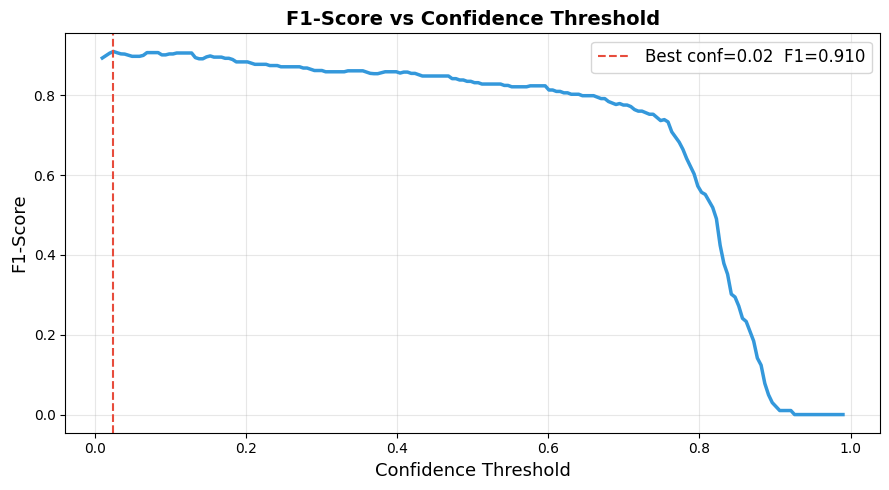

✅ Saved & displayed f1_curve.png  |  Best F1=0.9095 @ conf=0.02


In [19]:
thresholds_list = np.linspace(0.01, 0.99, 200)
f1_scores_list  = []

for t in thresholds_list:
    preds_t = (all_scores >= t).astype(int)
    f1 = f1_score(all_labels_gt, preds_t, zero_division=0)
    f1_scores_list.append(f1)

best_idx = np.argmax(f1_scores_list)
best_conf = thresholds_list[best_idx]
best_f1   = f1_scores_list[best_idx]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds_list, f1_scores_list, color="#3498db", linewidth=2.5)
ax.axvline(best_conf, color="#e74c3c", linestyle="--", label=f"Best conf={best_conf:.2f}  F1={best_f1:.3f}")
ax.set_xlabel("Confidence Threshold", fontsize=13)
ax.set_ylabel("F1-Score", fontsize=13)
ax.set_title("F1-Score vs Confidence Threshold", fontsize=14, fontweight="bold")
ax.legend(fontsize=12); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_FIGS / "f1_curve.png", dpi=SAVE_DPI)
plt.show()  # Display the figure inline
print(f"✅ Saved & displayed f1_curve.png  |  Best F1={best_f1:.4f} @ conf={best_conf:.2f}")


## 7. Precision Curve

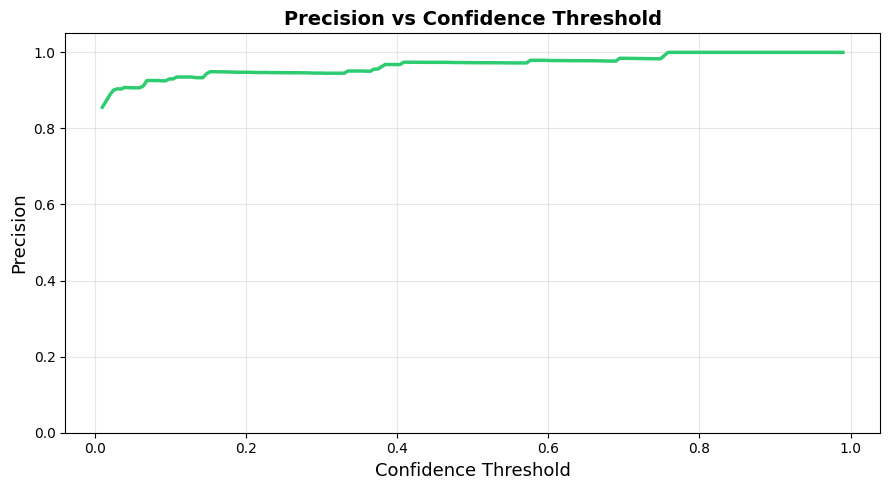

✅ Saved & displayed precision_curve.png


In [20]:
prec_list = []
for t in thresholds_list:
    preds_t = (all_scores >= t).astype(int)
    tp_ = ((preds_t == 1) & (all_labels_gt == 1)).sum()
    fp_ = ((preds_t == 1) & (all_labels_gt == 0)).sum()
    prec_list.append(tp_ / (tp_ + fp_) if (tp_ + fp_) > 0 else 1.0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds_list, prec_list, color="#2ecc71", linewidth=2.5)
ax.set_xlabel("Confidence Threshold", fontsize=13)
ax.set_ylabel("Precision", fontsize=13)
ax.set_title("Precision vs Confidence Threshold", fontsize=14, fontweight="bold")
ax.set_ylim([0, 1.05]); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_FIGS / "precision_curve.png", dpi=SAVE_DPI)
plt.show()  # Display the figure inline
print("✅ Saved & displayed precision_curve.png")


## 8. Recall Curve

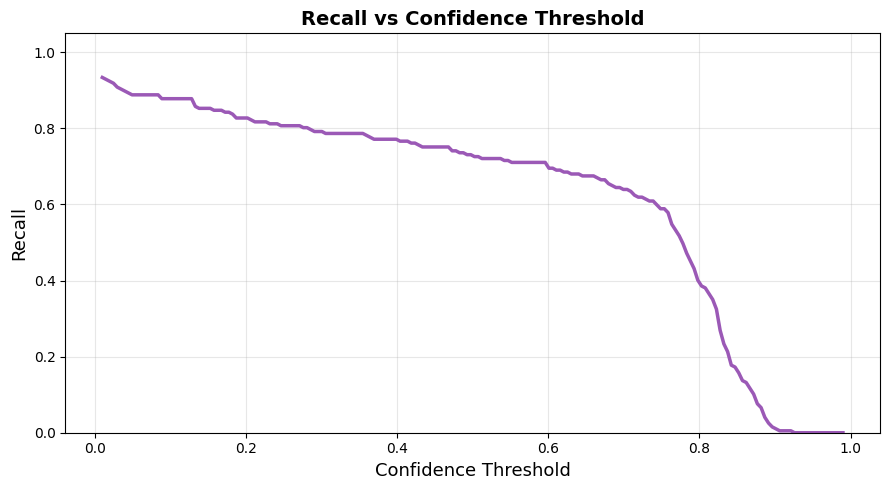

✅ Saved & displayed recall_curve.png


In [21]:
rec_list = []
for t in thresholds_list:
    preds_t = (all_scores >= t).astype(int)
    tp_ = ((preds_t == 1) & (all_labels_gt == 1)).sum()
    fn_ = ((preds_t == 0) & (all_labels_gt == 1)).sum()
    rec_list.append(tp_ / (tp_ + fn_) if (tp_ + fn_) > 0 else 0.0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds_list, rec_list, color="#9b59b6", linewidth=2.5)
ax.set_xlabel("Confidence Threshold", fontsize=13)
ax.set_ylabel("Recall", fontsize=13)
ax.set_title("Recall vs Confidence Threshold", fontsize=14, fontweight="bold")
ax.set_ylim([0, 1.05]); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_FIGS / "recall_curve.png", dpi=SAVE_DPI)
plt.show()  # Display the figure inline
print("✅ Saved & displayed recall_curve.png")


## 9. mAP Curve (across IoU thresholds)

Computing mAP across IoU thresholds...


  0%|          | 0/10 [00:00<?, ?it/s]

Ultralytics 8.4.21  Python-3.10.19 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 203.4195.8 MB/s, size: 258.5 KB)
val: Scanning D:\Project Medical Object Detection\FracAtlas\yolo_dataset_hand_oversampled\test\labels.cache... 362 images, 165 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 362/362  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 8.8s/it 3:238.9ss
                   all        362        253      0.644      0.371      0.493      0.232
Speed: 7.0ms preprocess, 543.4ms inference, 0.0ms loss, 0.7ms postprocess per image


 10%|█         | 1/10 [03:59<35:54, 239.39s/it]

Ultralytics 8.4.21  Python-3.10.19 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
val: Fast image access  (ping: 0.20.0 ms, read: 49.216.3 MB/s, size: 33.0 KB)
val: Scanning D:\Project Medical Object Detection\FracAtlas\yolo_dataset_hand_oversampled\test\labels.cache... 362 images, 165 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 362/362  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 9.0s/it 3:279.2ss
                   all        362        253      0.634       0.37      0.489       0.23
Speed: 12.6ms preprocess, 550.8ms inference, 0.0ms loss, 1.2ms postprocess per image


...

 80%|████████  | 8/10 [32:52<08:10, 245.21s/it]

Ultralytics 8.4.21  Python-3.10.19 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
val: Fast image access  (ping: 0.20.0 ms, read: 76.268.3 MB/s, size: 127.4 KB)
val: Scanning D:\Project Medical Object Detection\FracAtlas\yolo_dataset_hand_oversampled\test\labels.cache... 362 images, 165 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 362/362  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 8.8s/it 3:238.9ss
                   all        362        253      0.471       0.32      0.356      0.176
Speed: 8.5ms preprocess, 546.8ms inference, 0.0ms loss, 0.8ms postprocess per image


 90%|█████████ | 9/10 [36:50<04:02, 242.69s/it]

Ultralytics 8.4.21  Python-3.10.19 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
val: Fast image access  (ping: 0.20.1 ms, read: 51.316.8 MB/s, size: 26.4 KB)
val: Scanning D:\Project Medical Object Detection\FracAtlas\yolo_dataset_hand_oversampled\test\labels.cache... 362 images, 165 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 362/362 225.7Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 8.8s/it 3:228.9ss
                   all        362        253      0.416      0.229      0.252      0.127
Speed: 8.4ms preprocess, 544.9ms inference, 0.0ms loss, 0.7ms postprocess per image


100%|██████████| 10/10 [40:43<00:00, 244.37s/it]


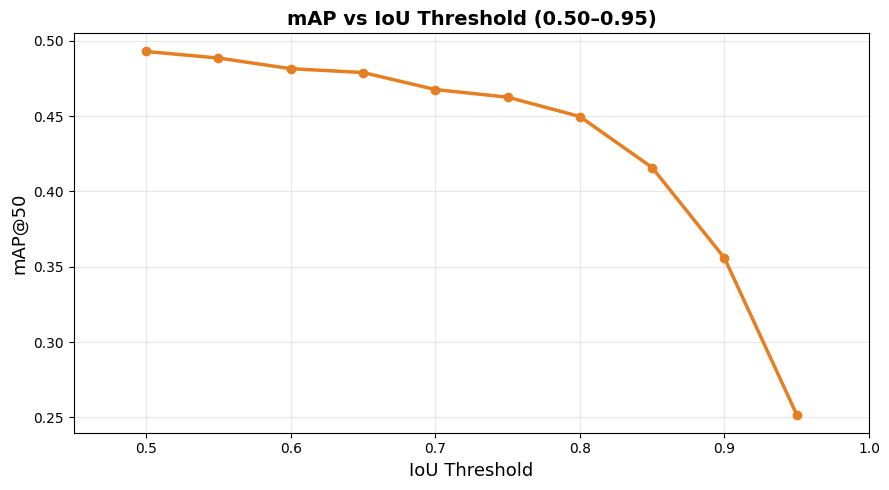

✅ Saved & displayed map_curve.png


In [22]:
# Approximate mAP across IoU thresholds by running val at different IoU values
iou_thresholds = np.arange(0.50, 1.00, 0.05)
map_per_iou    = []

print("Computing mAP across IoU thresholds...")
for iou_t in tqdm(iou_thresholds):
    r = model.val(data=str(YAML_PATH), split="test", imgsz=1024,
                  conf=0.25, iou=float(iou_t), verbose=False, plots=False,
                  project=str(RUNS_DIR), name="_tmp_iou", exist_ok=True)
    map50_t = float(r.results_dict.get("metrics/mAP50(B)", 0))
    map_per_iou.append(map50_t)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(iou_thresholds, map_per_iou, "o-", color="#e67e22", linewidth=2.5, markersize=6)
ax.set_xlabel("IoU Threshold", fontsize=13)
ax.set_ylabel("mAP@50", fontsize=13)
ax.set_title("mAP vs IoU Threshold (0.50–0.95)", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.set_xlim([0.45, 1.0])
plt.tight_layout()
plt.savefig(OUTPUT_FIGS / "map_curve.png", dpi=SAVE_DPI)
plt.show()  # Display the figure inline
print("✅ Saved & displayed map_curve.png")


## 10. Training Metrics Graph

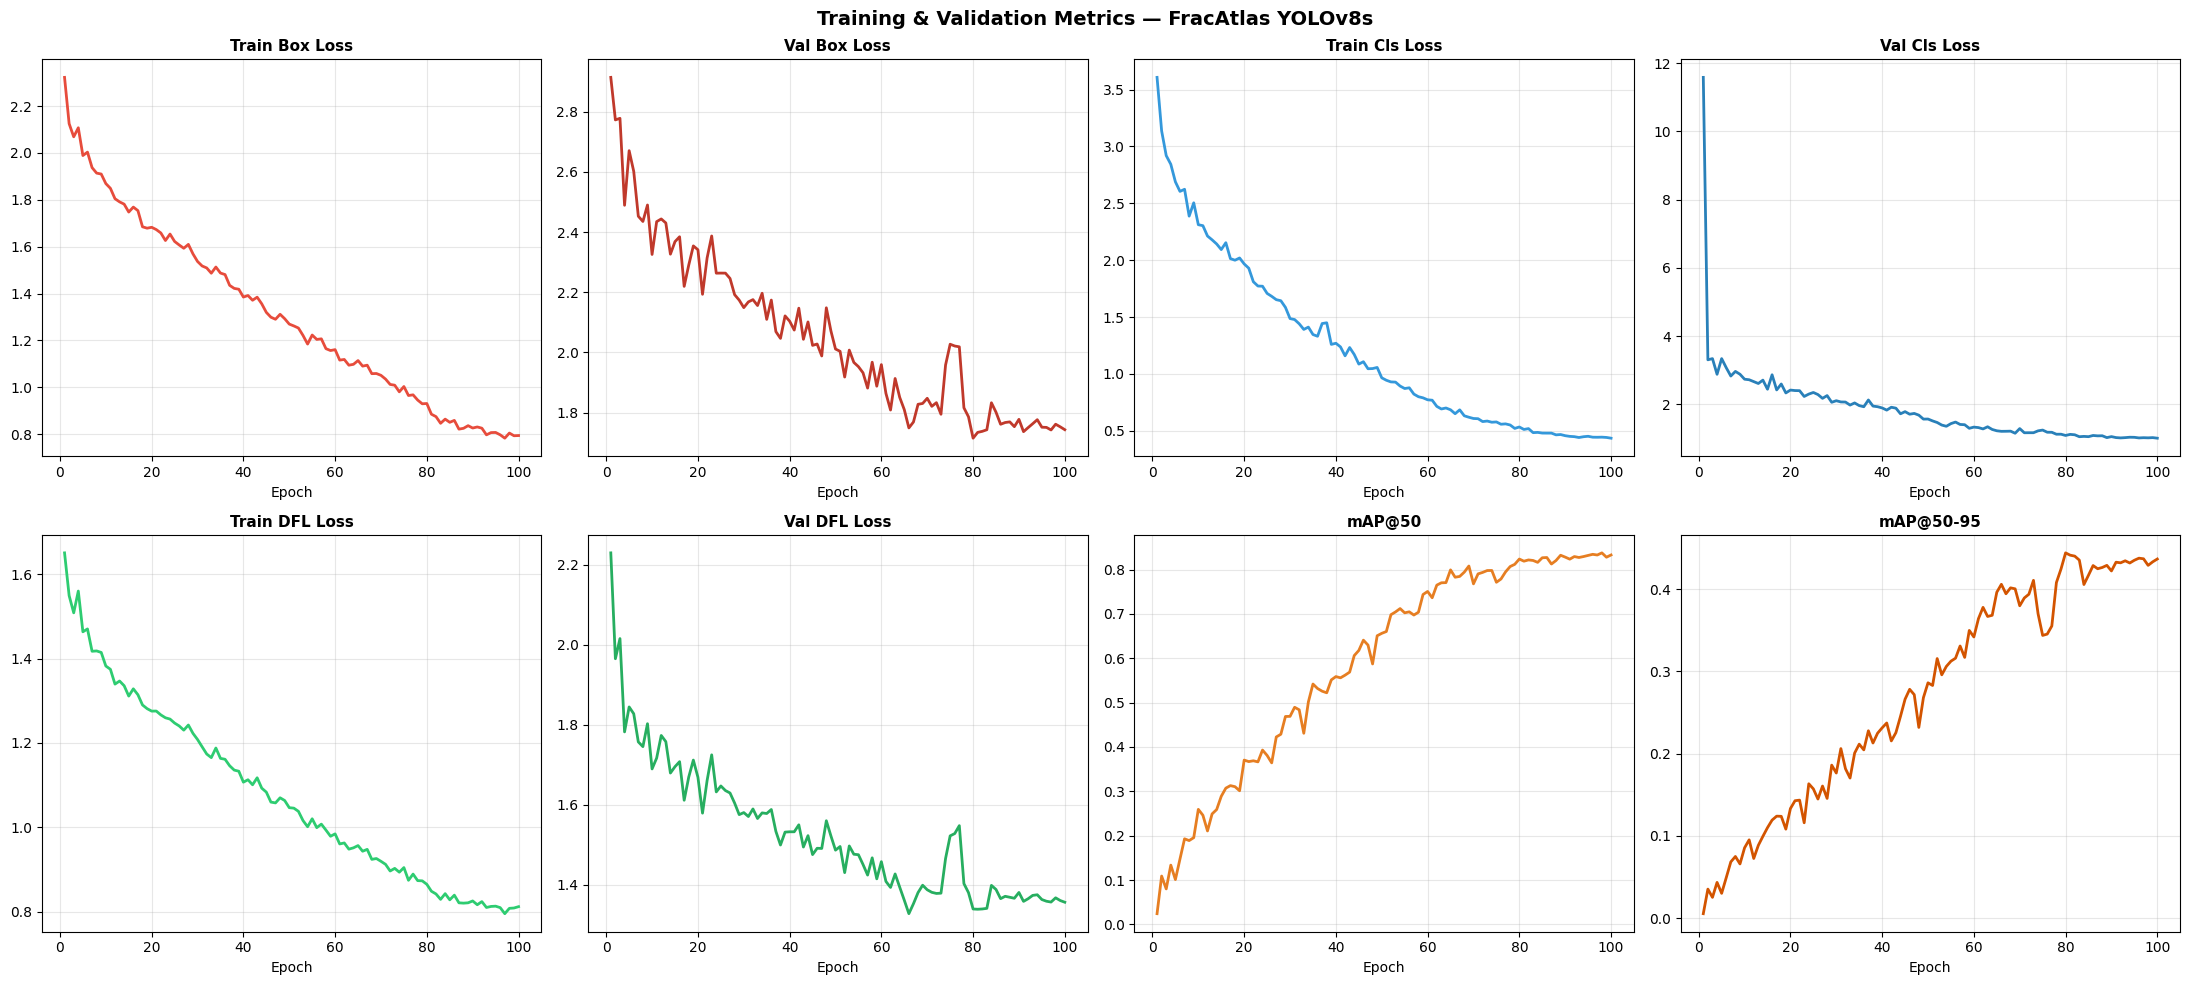

✅ Saved & displayed training_metrics.png


In [23]:
results_csv = RUNS_DIR / RUN_NAME / "results.csv"

if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    axes = axes.flatten()

    cols_to_plot = [
        ("train/box_loss",      "Train Box Loss",    "#e74c3c"),
        ("val/box_loss",        "Val Box Loss",      "#c0392b"),
        ("train/cls_loss",      "Train Cls Loss",    "#3498db"),
        ("val/cls_loss",        "Val Cls Loss",      "#2980b9"),
        ("train/dfl_loss",      "Train DFL Loss",    "#2ecc71"),
        ("val/dfl_loss",        "Val DFL Loss",      "#27ae60"),
        ("metrics/mAP50(B)",    "mAP@50",            "#e67e22"),
        ("metrics/mAP50-95(B)", "mAP@50-95",         "#d35400"),
    ]

    for ax, (col, title, color) in zip(axes, cols_to_plot):
        if col in df.columns:
            ax.plot(df["epoch"], df[col], color=color, linewidth=2)
            ax.set_title(title, fontsize=11, fontweight="bold")
            ax.set_xlabel("Epoch"); ax.grid(True, alpha=0.3)
        else:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(title, fontsize=11)

    plt.suptitle("Training & Validation Metrics — FracAtlas YOLOv8s",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUTPUT_FIGS / "training_metrics.png", dpi=SAVE_DPI)
    plt.show()  # Display the figure inline
    print("✅ Saved & displayed training_metrics.png")
else:
    print(f"⚠️  {results_csv} not found. Run Notebook 02 first.")


## 11. Summary Table

In [24]:
summary = {
    "Metric": ["Precision", "Recall", "F1-Score", "mAP@50", "mAP@50-95",
               "Best F1 Threshold", "Average Precision (PR)"],
    "Value":  [f"{mp:.4f}", f"{mr:.4f}", f"{f1_val:.4f}",
               f"{map50:.4f}", f"{map5095:.4f}",
               f"{best_conf:.2f}", f"{ap:.4f}"],
}
df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False))

# Save as CSV
df_summary.to_csv(OUTPUT_FIGS / "evaluation_summary.csv", index=False)
print("\n✅ Saved evaluation_summary.csv")
print("\n📝 Saved evaluation figures:")
for f in ["precision_recall_curve.png", "confusion_matrix.png", "map_curve.png",
          "f1_curve.png", "precision_curve.png", "recall_curve.png", "training_metrics.png"]:
    exists = (OUTPUT_FIGS / f).exists()
    print(f"   {'✅' if exists else '❌'} {f}")


                Metric  Value
             Precision 0.8083
                Recall 0.7747
              F1-Score 0.7912
                mAP@50 0.8420
             mAP@50-95 0.4345
     Best F1 Threshold   0.02
Average Precision (PR) 0.9545

✅ Saved evaluation_summary.csv

📝 Saved evaluation figures:
   ✅ precision_recall_curve.png
   ✅ confusion_matrix.png
   ✅ map_curve.png
   ✅ f1_curve.png
   ✅ precision_curve.png
   ✅ recall_curve.png
   ✅ training_metrics.png
